# GCN accuracy across transport modes (ON_FOOT vs. CAR vs. BICYCLE)

Compares the *same* GCN architecture (`model_architecture.GCNResNet`) trained
independently per mode - `scripts/train_onfoot.py`, `scripts/train_car.py`,
`scripts/train_bicycle.py` - each with its own 29-feature-per-TAZ input, 7
POI-category output, and (per the `maat_rl_intro-1` ablation) its own dedicated
model rather than one joint multi-mode model.

Doesn't recompute anything live - `scripts/evaluate_{mode}.py` already saved a
TAZ-level `eval_results.pkl` into each run's own folder; this notebook just loads
and compares those three pickles.

Note: CAR and BICYCLE trained on ~4,500 scenarios (vs. ON_FOOT's ~22,000) and use
a pseudo (min-water-depth stand-in) dry baseline rather than a real zero-flood
scenario - see `data_car.py`/`data_bicycle.py`'s `save_pseudo_dry_baseline`.

In [1]:
import glob
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qol_surrogate.data_onfoot import ZONES_FILE, load_hexes, build_taz_geometries

/home/mmego/micromamba/envs/maat/lib/python3.11/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


In [2]:
MODELS_DIR = "../models"

MODES = [
    ("onfoot", "ON_FOOT", "#55A868"),   # green
    ("car", "CAR", "#DD8452"),          # amber
    ("bicycle", "BICYCLE", "#4C72B0"),  # blue
]

run_dirs = {}
for key, label, color in MODES:
    dirs = sorted(d for d in glob.glob(os.path.join(MODELS_DIR, f"gcn_resnet_{key}_*")) if os.path.isdir(d))
    run_dirs[key] = dirs[-1]
    print(f"{label:8s}: {run_dirs[key]}")

ON_FOOT : ../models/gcn_resnet_onfoot_20260821_090546
CAR     : ../models/gcn_resnet_car_20260912_021318
BICYCLE : ../models/gcn_resnet_bicycle_20260912_000655


In [3]:
def load_eval_results(run_dir, mode_key):
    results_path = os.path.join(run_dir, "eval_results.pkl")
    if not os.path.exists(results_path):
        raise FileNotFoundError(
            f"{results_path} doesn't exist yet - run `python scripts/evaluate_{mode_key}.py "
            f"{run_dir}` first, then re-run this cell."
        )
    with open(results_path, "rb") as f:
        return pickle.load(f)


results_by_key = {key: load_eval_results(run_dirs[key], key) for key, _, _ in MODES}
print("Loaded all three eval_results.pkl")

Loaded all three eval_results.pkl


## Pooled TAZ-level accuracy (all 277 zones combined)

Both deviation (what each model is actually trained to predict) and absolute
(deviation + dry baseline).

In [4]:
pooled = pd.DataFrame({
    f"{key}_deviation": results_by_key[key]["taz"]["deviation"]["overall"] for key, _, _ in MODES
} | {
    f"{key}_absolute": results_by_key[key]["taz"]["absolute"]["overall"] for key, _, _ in MODES
})
pooled

,onfoot_deviation,car_deviation,bicycle_deviation,onfoot_absolute,car_absolute,bicycle_absolute
r2,0.978354,0.974134,0.975682,0.997937,0.997939,0.996255
mae,0.315009,6.517557,2.843658,0.315009,6.517557,2.843658
c_index,0.936624,0.943641,0.950064,0.987816,0.987498,0.983303
wape,0.127318,0.119728,0.107644,0.023096,0.014173,0.027853


## Overall accuracy (%)

Same composite score used in `maat_rl_intro-1/compare_models_mcosta.ipynb` and in
`compare_baseline_onfoot.ipynb`: the mean of R2, (100 - WAPE), and C-index, each
expressed on a 0-100 "% of best possible" scale. R2 and C-index are already 0-1
with 1.0 = perfect, so *100 puts them on that scale directly. WAPE is already a
percentage but is an *error* (lower = better), so it's inverted to (100 - WAPE)
first, making all three higher-is-better before averaging. Computed from the
pooled (all TAZs, all POI categories), absolute-accessibility overall metrics.

In [5]:
def overall_accuracy_pct(overall_metrics):
    r2, wape, c_index = overall_metrics["r2"], overall_metrics["wape"], overall_metrics["c_index"]
    return (r2 * 100 + (100 - wape * 100) + c_index * 100) / 3


overall_acc = {label: overall_accuracy_pct(results_by_key[key]["taz"]["absolute"]["overall"]) for key, label, _ in MODES}
for label, acc in overall_acc.items():
    print(f"{label}: {acc:.1f}% overall accuracy")

ON_FOOT: 98.8% overall accuracy
CAR: 99.0% overall accuracy
BICYCLE: 98.4% overall accuracy


## City-wide accuracy, by POI category

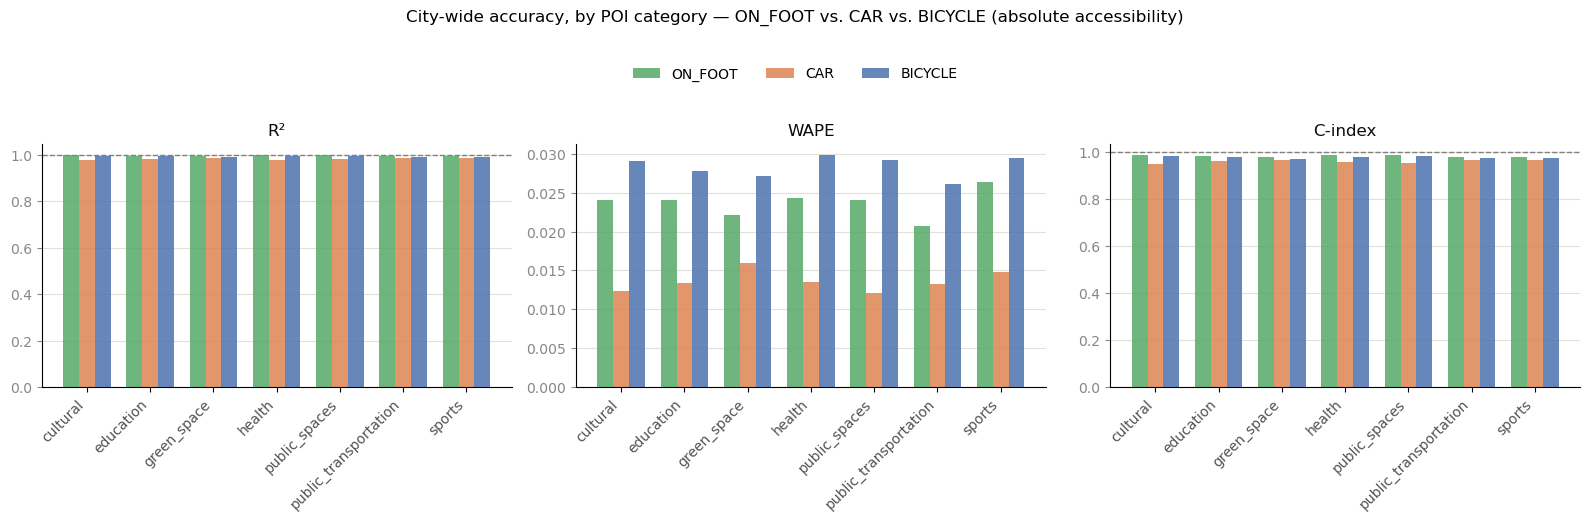

In [6]:
POI_CATEGORIES = ['cultural', 'education', 'green_space', 'health',
                   'public_spaces', 'public_transportation', 'sports']

METRICS = ["r2", "wape", "c_index"]
METRIC_LABELS = {"r2": "R\u00b2", "wape": "WAPE", "c_index": "C-index"}
METRICS_WITH_MAX_1 = {"r2", "c_index"}

INK_MUTED = "#898781"
INK_SECONDARY = "#52514e"
GRID_COLOR = "#e1e0d9"
BAR_WIDTH = 0.25

x = np.arange(len(POI_CATEGORIES))
offsets = [-BAR_WIDTH, 0, BAR_WIDTH]

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 4.5))

for ax, metric in zip(axes, METRICS):
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    for (key, label, color), offset in zip(MODES, offsets):
        vals = [results_by_key[key]["taz"]["absolute"]["per_channel"][c][metric] for c in POI_CATEGORIES]
        ax.bar(x + offset, vals, width=BAR_WIDTH, color=color, alpha=0.85, zorder=2, label=label)

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", zorder=1)

    ax.set_xticks(x)
    ax.set_xticklabels(POI_CATEGORIES, rotation=45, ha="right", color=INK_SECONDARY)
    ax.set_title(METRIC_LABELS[metric], color="#0b0b0b")
    ax.tick_params(axis="y", colors=INK_MUTED)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)
fig.suptitle("City-wide accuracy, by POI category \u2014 ON_FOOT vs. CAR vs. BICYCLE (absolute accessibility)", y=1.15)
fig.tight_layout()
plt.show()

## Per-TAZ accuracy

Per-TAZ R2, WAPE, and C-index (absolute accessibility, pooled over the 7 POI
categories and every test scenario within each zone).

In [7]:
per_taz_by_key = {key: results_by_key[key]["taz_per_taz"] for key, _, _ in MODES}
per_taz_by_key["onfoot"]["r2"].describe()

,ON_FOOT
count,277.000000
mean,0.995175
std,0.004672
min,0.960361
25%,0.994156
50%,0.996354
75%,0.997829
max,0.999361


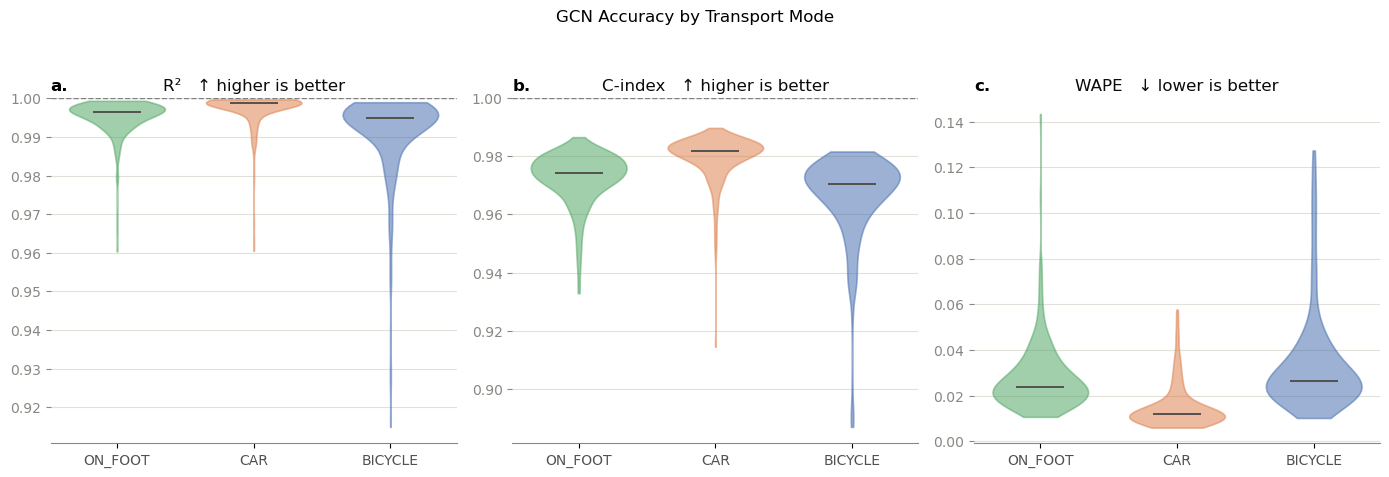

In [8]:
VIOLIN_METRICS = ["r2", "c_index", "wape"]  # the two 1.0-capped metrics side by side, WAPE (uncapped) last
VIOLIN_TITLES = {
    "r2": "R\u00b2   \u2191 higher is better",
    "c_index": "C-index   \u2191 higher is better",
    "wape": "WAPE   \u2193 lower is better",
}
VIOLIN_LABELS = {"r2": "a.", "c_index": "b.", "wape": "c."}

fig, axes = plt.subplots(1, len(VIOLIN_METRICS), figsize=(14, 4.5))

for ax, metric in zip(axes, VIOLIN_METRICS):
    data = [per_taz_by_key[key][metric][label].dropna().to_numpy() for key, label, _ in MODES]

    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    vp = ax.violinplot(data, positions=[0, 1, 2], widths=0.7,
                        showmedians=True, showextrema=False)
    for body, (_, _, color) in zip(vp["bodies"], MODES):
        body.set_facecolor(color); body.set_edgecolor(color); body.set_alpha(0.55); body.set_linewidth(1.2)
    vp["cmedians"].set_color(INK_SECONDARY); vp["cmedians"].set_linewidth(1.4)

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", zorder=1)
        ymin, _ = ax.get_ylim()
        ax.set_ylim(ymin, 1.0)  # capped - nothing plotted above 1.0 is shown

    ax.set_xticks([0, 1, 2]); ax.set_xticklabels([label for _, label, _ in MODES], color=INK_SECONDARY)
    ax.set_title(VIOLIN_LABELS[metric], loc="left", fontweight="bold")
    ax.set_title(VIOLIN_TITLES[metric], loc="center", color="#0b0b0b")
    ax.tick_params(axis="y", colors=INK_MUTED)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(INK_MUTED)

fig.suptitle("GCN Accuracy by Transport Mode", y=1.05)
fig.tight_layout()
plt.show()

## Per-TAZ maps

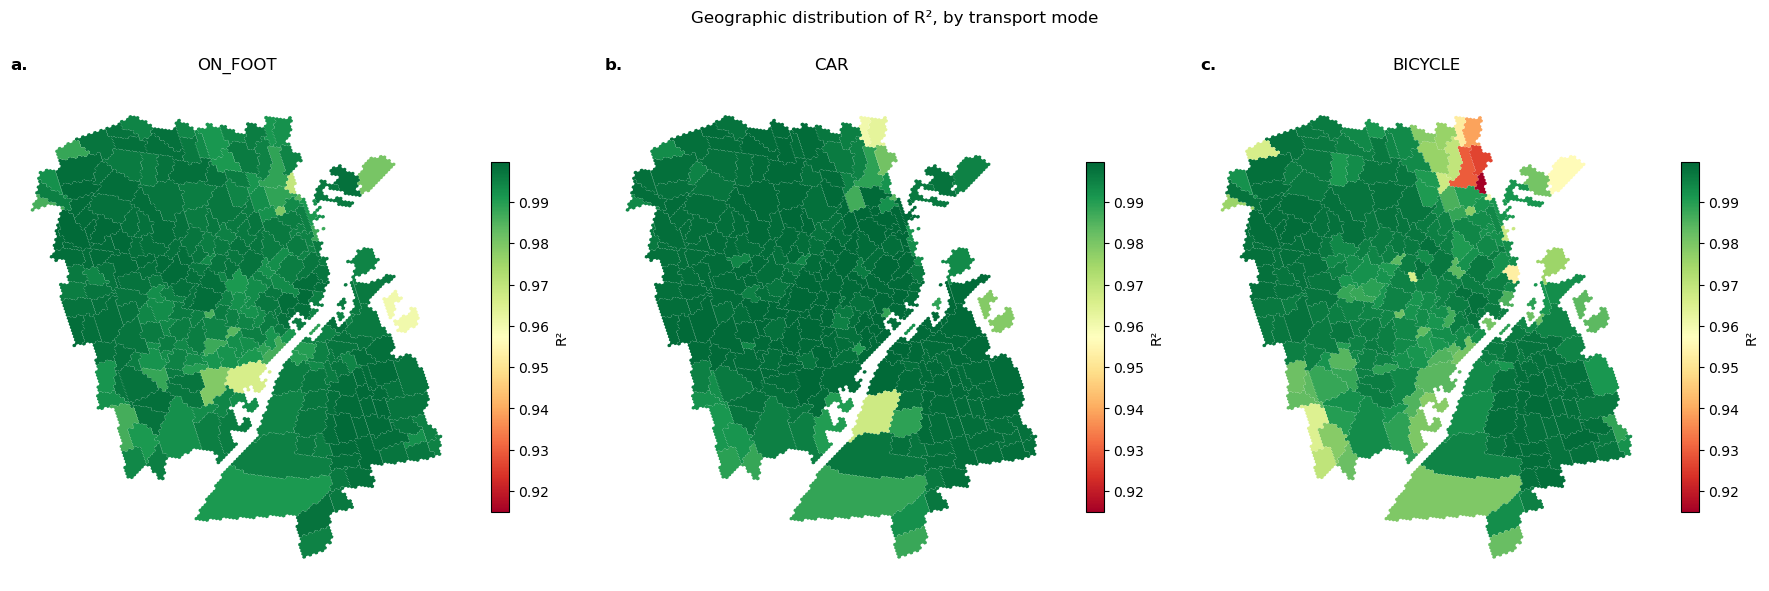

In [9]:
hexes = load_hexes(ZONES_FILE)
tazes = build_taz_geometries(hexes)

r2_by_key = {key: per_taz_by_key[key]["r2"][label] for key, label, _ in MODES}

r2_vmin = min(s.min() for s in r2_by_key.values())
r2_vmax = max(s.max() for s in r2_by_key.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panel_labels = ["a.", "b.", "c."]

for ax, (key, label, _), panel_label in zip(axes, MODES, panel_labels):
    df = tazes.join(r2_by_key[key].rename("value"))
    df.plot(column="value", cmap="RdYlGn", vmin=r2_vmin, vmax=r2_vmax, legend=True, ax=ax,
             legend_kwds={"label": "R\u00b2", "shrink": 0.65})
    ax.set_title(panel_label, loc="left", fontweight="bold")
    ax.set_title(label, loc="center")
    ax.set_axis_off()

fig.suptitle("Geographic distribution of R\u00b2, by transport mode", y=1.02)
plt.tight_layout()
plt.show()